# 分割

我们已经学习了对象检测，它可以通过预测*边界框*来定位图像中的对象。然而，对于某些任务，我们不仅需要边界框，还需要更精确的对象定位。这项任务被称为**分割**。

分割可以看作是**像素分类**，即对于图像中的**每个**像素，我们必须预测其类别（*背景*是其中一个类别）。主要有两种分割算法：

* **语义分割**只标识像素的类别，不区分同一类别中的不同对象
* **实例分割**将类别划分为不同的实例。

例如，在实例分割中，10只羊是不同的对象；而在语义分割中，所有的羊都被表示为一个类别。

<img src="images/instance_vs_semantic.jpeg" width="50%">

> 图片来源于[这篇博客文章](https://nirmalamurali.medium.com/image-classification-vs-semantic-segmentation-vs-instance-segmentation-625c33a08d50)

分割有不同的神经网络架构，但它们的结构都相同：

* **编码器**从输入图像中提取特征
* **解码器**将这些特征转换为**掩码图像**，掩码图像的大小与输入图像相同，通道数对应类别数量。

<img src="images/segm.png" width="80%">

> 图片来源于[这篇论文](https://arxiv.org/pdf/2001.05566.pdf)


## 前置条件

首先，我们将导入所需的库，并检查是否有可用于训练的 GPU。


In [1]:
import torch
import torchvision
import matplotlib.pyplot as plt
from torchvision import transforms
from torch import nn
from torch import optim
from tqdm import tqdm
import numpy as np
import torch.nn.functional as F
from skimage.io import imread
from skimage.transform import resize
import os
torch.manual_seed(42)
np.random.seed(42)

D:\Anaconda\envs\ai4beg\Lib\site-packages\skimage\color\colorconv.py:55: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.3.5)
  from scipy import linalg


In [2]:
device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
train_size = 0.9
lr = 1e-3
weight_decay = 1e-6
batch_size = 32
epochs = 30

## 数据集

我们将使用人类痣的皮肤镜图像数据集。该数据集包含200张图像，分为三类：典型痣、非典型痣和黑色素瘤。所有图像还包含对应的**掩膜**，用于勾勒出痣的轮廓。

以下代码从原始位置下载数据集并解压缩。要运行此代码，您需要安装 `unrar` 工具。在 Linux 系统上，可以通过运行 `sudo apt-get install unrar` 安装；在 Windows 系统上，可以从[这里](https://www.rarlab.com/rar_add.htm)下载命令行版本。


In [10]:
!apt-get install rar
# !wget https://www.dropbox.com/s/k88qukc20ljnbuo/PH2Dataset.rar
!unrar x -Y PH2Dataset.rar

'apt-get' �����ڲ����ⲿ���Ҳ���ǿ����еĳ���
���������ļ���
'unrar' �����ڲ����ⲿ���Ҳ���ǿ����еĳ���
���������ļ���


现在我们将定义加载数据集的代码。我们会将所有图像转换为256x256大小，并将数据集分为训练集和测试集。此函数返回训练集和测试集，每个数据集包含原始图像和标注痣的掩码。


os.walk(top) 是一个生成器，它会遍历以 top 为根目录的整个目录树。在每次迭代中，它会返回一个包含三个元素的元组 (root, dirs, files)：
root: 当前正在遍历的目录的路径字符串。
dirs: 一个列表，包含 root 目录中所有子目录的名称（不包含路径）。
files: 一个列表，包含 root 目录中所有文件的名称（不包含路径）。
os.walk 会递归地进入 dirs 列表中的每个子目录，继续进行遍历。

PH2Dataset/

└── PH2 Dataset images

    ├── patient001/

    │   ├── patient001_Dermoscopic_Image/
    │   │   └── IMAGE.bmp
    │   └── patient001_lesion/
    │       └── MASK.bmp
    ├── patient002/
    │   ├── patient002_Dermoscopic_Image/
    │   │   └── IMAGE.bmp
    │   └── patient002_lesion/
    │       └── MASK.bmp
    └── patient003/
        ├── patient003_Dermoscopic_Image/
        │   └── IMAGE.bmp
        └── patient003_lesion/
            └── MASK.bmp

### 第一次迭代:

root: 'PH2Dataset/PH2 Dataset images'
dirs: ['patient001', 'patient002', 'patient003']
files: [] (假设这个目录下没有直接的文件)
你的代码判断：
root 不以 '_Dermoscopic_Image' 或 '_lesion' 结尾，所以不执行任何操作。
os.walk 会记下 dirs 列表中的三个目录，接下来会逐个进入它们进行遍历。

### 第二次迭代 (进入 patient001):
root: 'PH2Dataset/PH2 Dataset images/patient001'
dirs: ['patient001_Dermoscopic_Image', 'patient001_lesion']
files: []
你的代码判断：
root 不以 '_Dermoscopic_Image' 或 '_lesion' 结尾，不执行任何操作。
os.walk 会记下 dirs 列表中的两个目录，接下来会进入它们。
### 第三次迭代 (进入 patient001_Dermoscopic_Image):
root: 'PH2Dataset/PH2 Dataset images/patient001/patient001_Dermoscopic_Image'
dirs: [] (假设这个目录下没有子目录)
files: ['IMAGE.bmp']
你的代码判断：
root.endswith('_Dermoscopic_Image') → True
执行 images.append(imread(os.path.join(root, files[0])))
os.path.join(root, files[0]) → 'PH2Dataset/PH2 Dataset images/patient001/patient001_Dermoscopic_Image/IMAGE.bmp'
images 列表现在包含了 patient001 的皮肤镜图像。

In [22]:
def load_dataset(train_part, root='PH2Dataset'):
    images = []
    masks = []

    for root, dirs, files in os.walk(os.path.join(root, 'PH2 Dataset images')):
        if root.endswith('_Dermoscopic_Image'):
            images.append(imread(os.path.join(root, files[0])))
        if root.endswith('_lesion'):
            masks.append(imread(os.path.join(root, files[0])))

    size = (256, 256)
    images = torch.permute(torch.FloatTensor(np.array([resize(image, size, mode='constant', anti_aliasing=True,) for image in images])), (0, 3, 1, 2))
    #得到(N, C, H, W)。而刚刚得到的 Tensor 格式是 (N, H, W, C)。permute 函数用于重新排列维度，将通道维度 3 移动到第二个位置。
    masks = torch.FloatTensor(np.array([resize(mask, size, mode='constant', anti_aliasing=False) > 0.5 for mask in masks])).unsqueeze(1)
    #掩码图像是包含标签的部分，告诉哪些地方是有zhi的
    indices = np.random.permutation(range(len(images)))
    #生成随机打乱的索引
    train_part = int(train_part * len(images))
    train_ind = indices[:train_part]
    test_ind = indices[train_part:]

    train_dataset = (images[train_ind, :, :, :], masks[train_ind, :, :, :])
    test_dataset = (images[test_ind, :, :, :], masks[test_ind, :, :, :])

    return train_dataset, test_dataset

train_dataset, test_dataset = load_dataset(train_size)

注意，此时train_dataset是元组，train_dataset[0]是图片，train_dataset[1]是标签

我们希望的是同时得到一对图片和标签，所以要
```
zip(train_dataset[0],train_dataset[1])
```
来打包

现在让我们绘制一些数据集中的图像，看看它们的样子：


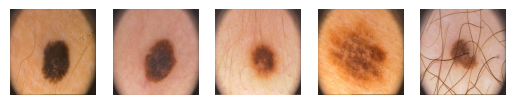

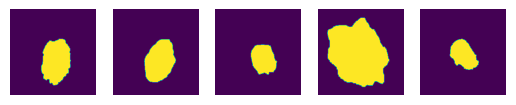

In [14]:
def plotn(n, data, only_mask=False):
    images, masks = data[0], data[1]
    fig, ax = plt.subplots(1, n)
    fig1, ax1 = plt.subplots(1, n)
    for i, (img, mask) in enumerate(zip(images, masks)):
        if i == n:
            break
        if not only_mask:
            ax[i].imshow(torch.permute(img, (1, 2, 0)))
        else:
            ax[i].imshow(img[0])#显示的红色通道
        ax1[i].imshow(mask[0])
        ax[i].axis('off')
        ax1[i].axis('off')
    plt.show()

plotn(5, train_dataset)

我们还需要数据加载器将数据输入到我们的神经网络中。


In [15]:
train_dataloader = torch.utils.data.DataLoader(list(zip(train_dataset[0], train_dataset[1])), batch_size=batch_size, shuffle=True)
test_dataloader = torch.utils.data.DataLoader(list(zip(test_dataset[0], test_dataset[1])), batch_size=1, shuffle=False)
dataloaders = (train_dataloader, test_dataloader)

## SegNet

最简单的编码-解码架构被称为 **SegNet**。它在编码器中使用标准的卷积神经网络（CNN），包括卷积和池化操作；在解码器中使用反卷积神经网络（CNN），包括卷积和上采样操作。它还依赖批量归一化来成功训练多层网络。

<img src="images/segnet.png" width="80%">

> 图片来源于以下论文：Badrinarayanan, V., Kendall, A., & Cipolla, R. (2015). [SegNet: A deep convolutional
encoder-decoder architecture for image segmentation](https://arxiv.org/pdf/1511.00561.pdf)


In [23]:
class SegNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc_conv0 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=(3,3), padding=1)
        self.act0 = nn.ReLU()
        self.bn0 = nn.BatchNorm2d(16)
        self.pool0 = nn.MaxPool2d(kernel_size=(2,2))

        self.enc_conv1 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=(3,3), padding=1)
        self.act1 = nn.ReLU()
        self.bn1 = nn.BatchNorm2d(32)
        self.pool1 = nn.MaxPool2d(kernel_size=(2,2))

        self.enc_conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=(3,3), padding=1)
        self.act2 = nn.ReLU()
        self.bn2 = nn.BatchNorm2d(64)
        self.pool2 =  nn.MaxPool2d(kernel_size=(2,2))

        self.enc_conv3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=(3,3), padding=1)
        self.act3 = nn.ReLU()
        self.bn3 = nn.BatchNorm2d(128)
        self.pool3 =  nn.MaxPool2d(kernel_size=(2,2))

        self.bottleneck_conv = nn.Conv2d(in_channels=128, out_channels=256, kernel_size=(3,3), padding=1)
        
        self.upsample0 =  nn.UpsamplingBilinear2d(scale_factor=2)
        self.dec_conv0 = nn.Conv2d(in_channels=256, out_channels=128, kernel_size=(3,3), padding=1)
        self.dec_act0 = nn.ReLU()
        self.dec_bn0 = nn.BatchNorm2d(128)

        self.upsample1 =  nn.UpsamplingBilinear2d(scale_factor=2)
        self.dec_conv1 =  nn.Conv2d(in_channels=128, out_channels=64, kernel_size=(3,3), padding=1)
        self.dec_act1 = nn.ReLU()
        self.dec_bn1 = nn.BatchNorm2d(64)

        self.upsample2 = nn.UpsamplingBilinear2d(scale_factor=2)
        
        self.dec_conv2 = nn.Conv2d(in_channels=64, out_channels=32, kernel_size=(3,3), padding=1)
        self.dec_act2 = nn.ReLU()
        self.dec_bn2 = nn.BatchNorm2d(32)

        self.upsample3 = nn.UpsamplingBilinear2d(scale_factor=2)
        self.dec_conv3 = nn.Conv2d(in_channels=32, out_channels=1, kernel_size=(1,1))

        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        e0 = self.pool0(self.bn0(self.act0(self.enc_conv0(x))))
        e1 = self.pool1(self.bn1(self.act1(self.enc_conv1(e0))))
        e2 = self.pool2(self.bn2(self.act2(self.enc_conv2(e1))))
        e3 = self.pool3(self.bn3(self.act3(self.enc_conv3(e2))))

        b = self.bottleneck_conv(e3)

        d0 = self.dec_bn0(self.dec_act0(self.dec_conv0(self.upsample0(b))))
        d1 = self.dec_bn1(self.dec_act1(self.dec_conv1(self.upsample1(d0))))
        d2 = self.dec_bn2(self.dec_act2(self.dec_conv2(self.upsample2(d1))))
        d3 = self.dec_conv3(self.upsample3(d2))
        return d3

我们特别需要提到用于分割的损失函数。在经典的自动编码器中，我们需要测量两张图像之间的相似性，可以使用均方误差来实现。在分割任务中，目标掩码图像中的每个像素表示类别编号（在第三维度上进行独热编码），因此我们需要使用特定于分类的损失函数——交叉熵损失，并对所有像素进行平均。如果掩码是二值的（如我们的示例）——我们将使用**二值交叉熵损失**（BCE）。


In [24]:
model = SegNet().to(device)
optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
loss_fn = nn.BCEWithLogitsLoss()

训练循环以通常的方式定义：


In [19]:
def train(dataloaders, model, loss_fn, optimizer, epochs, device):
    tqdm_iter = tqdm(range(epochs))
    train_dataloader, test_dataloader = dataloaders[0], dataloaders[1]

    for epoch in tqdm_iter:
        model.train()
        train_loss = 0.0
        test_loss = 0.0

        for batch in train_dataloader:
            imgs, labels = batch
            imgs = imgs.to(device)
            labels = labels.to(device)

            preds = model(imgs)
            loss = loss_fn(preds, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        model.eval()
        with torch.no_grad():
            for batch in test_dataloader:
                imgs, labels = batch
                imgs = imgs.to(device)
                labels = labels.to(device)

                preds = model(imgs)
                loss = loss_fn(preds, labels)

                test_loss += loss.item()

        train_loss /= len(train_dataloader)
        test_loss /= len(test_dataloader)

        tqdm_dct = {'train loss:': train_loss, 'test loss:': test_loss}
        tqdm_iter.set_postfix(tqdm_dct, refresh=True)
        tqdm_iter.refresh()

In [25]:
train(dataloaders, model, loss_fn, optimizer, epochs, device)

  0%|          | 0/30 [00:12<?, ?it/s]


KeyboardInterrupt: 

为了评估我们的模型，我们将仅绘制一些图像的目标掩码和预测掩码：


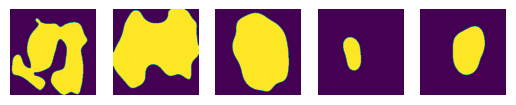

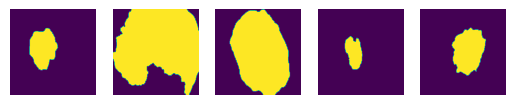

In [21]:
model.eval()
predictions = []
image_mask = []
plots = 5
images, masks = test_dataset[0], test_dataset[1]
for i, (img, mask) in enumerate(zip(images, masks)):
    if i == plots:
        break
    img = img.to(device).unsqueeze(0)
    predictions.append((model(img).detach().cpu()[0] > 0.5).float())
    image_mask.append(mask)
plotn(plots, (predictions, image_mask), only_mask=True)

也有一些正式指标来评估性能，您可以在[这里](https://towardsdatascience.com/metrics-to-evaluate-your-semantic-segmentation-model-6bcb99639aa2)阅读相关内容。最容易理解的是**像素准确率**——正确分类像素的百分比。


## U-Net

SegNet 的架构非常直观，但它并不是最准确的。实际上，我们首先对原始图像应用金字塔式的 CNN 架构，这会降低图像特征的空间精度。然后，当我们重建图像时，无法正确还原像素的位置。

这引出了在编码器和解码器的卷积层之间使用**跳跃连接**的想法。这种架构在语义分割中非常常见，被称为 **U-Net**。在每个卷积层级的跳跃连接可以帮助网络保留该层级原始输入的特征信息。

这里我们将使用相对简单的 CNN 架构，但 U-Net 也可以使用更复杂的编码器来提取特征，例如 ResNet-50。

<img src="images/unet.png" width="70%">

> 图片来源于论文：Ronneberger, Olaf, Philipp Fischer, 和 Thomas Brox. [U-Net: Convolutional networks for biomedical image segmentation.](https://arxiv.org/pdf/1505.04597.pdf)


In [14]:
class UNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc_conv0 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=(3,3), padding=1)
        self.act0 = nn.ReLU()
        self.bn0 = nn.BatchNorm2d(16)
        self.pool0 = nn.MaxPool2d(kernel_size=(2,2))

        self.enc_conv1 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=(3,3), padding=1)
        self.act1 = nn.ReLU()
        self.bn1 = nn.BatchNorm2d(32)
        self.pool1 = nn.MaxPool2d(kernel_size=(2,2))

        self.enc_conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=(3,3), padding=1)
        self.act2 = nn.ReLU()
        self.bn2 = nn.BatchNorm2d(64)
        self.pool2 =  nn.MaxPool2d(kernel_size=(2,2))

        self.enc_conv3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=(3,3), padding=1)
        self.act3 = nn.ReLU()
        self.bn3 = nn.BatchNorm2d(128)
        self.pool3 =  nn.MaxPool2d(kernel_size=(2,2))

        self.bottleneck_conv = nn.Conv2d(in_channels=128, out_channels=256, kernel_size=(3,3), padding=1)
        
        self.upsample0 =  nn.UpsamplingBilinear2d(scale_factor=2)
        self.dec_conv0 = nn.Conv2d(in_channels=384, out_channels=128, kernel_size=(3,3), padding=1)
        self.dec_act0 = nn.ReLU()
        self.dec_bn0 = nn.BatchNorm2d(128)

        self.upsample1 =  nn.UpsamplingBilinear2d(scale_factor=2)
        self.dec_conv1 =  nn.Conv2d(in_channels=192, out_channels=64, kernel_size=(3,3), padding=1)
        self.dec_act1 = nn.ReLU()
        self.dec_bn1 = nn.BatchNorm2d(64)

        self.upsample2 = nn.UpsamplingBilinear2d(scale_factor=2)
        self.dec_conv2 = nn.Conv2d(in_channels=96, out_channels=32, kernel_size=(3,3), padding=1)
        self.dec_act2 = nn.ReLU()
        self.dec_bn2 = nn.BatchNorm2d(32)

        self.upsample3 = nn.UpsamplingBilinear2d(scale_factor=2)
        self.dec_conv3 = nn.Conv2d(in_channels=48, out_channels=1, kernel_size=(1,1))

        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        e0 = self.pool0(self.bn0(self.act0(self.enc_conv0(x))))
        e1 = self.pool1(self.bn1(self.act1(self.enc_conv1(e0))))
        e2 = self.pool2(self.bn2(self.act2(self.enc_conv2(e1))))
        e3 = self.pool3(self.bn3(self.act3(self.enc_conv3(e2))))

        cat0 = self.bn0(self.act0(self.enc_conv0(x)))
        cat1 = self.bn1(self.act1(self.enc_conv1(e0)))
        cat2 = self.bn2(self.act2(self.enc_conv2(e1)))
        cat3 = self.bn3(self.act3(self.enc_conv3(e2)))

        b = self.bottleneck_conv(e3)

        d0 = self.dec_bn0(self.dec_act0(self.dec_conv0(torch.cat((self.upsample0(b), cat3), dim=1))))
        d1 = self.dec_bn1(self.dec_act1(self.dec_conv1(torch.cat((self.upsample1(d0), cat2), dim=1))))
        d2 = self.dec_bn2(self.dec_act2(self.dec_conv2(torch.cat((self.upsample2(d1), cat1), dim=1))))
        d3 = self.sigmoid(self.dec_conv3(torch.cat((self.upsample3(d2), cat0), dim=1)))
        return d3

In [15]:
model = UNet().to(device)
optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
loss_fn = nn.BCEWithLogitsLoss()

In [16]:
train(dataloaders, model, loss_fn, optimizer, epochs, device)

100%|██████████| 30/30 [29:07<00:00, 58.26s/it, train loss:=0.595, test loss:=0.572] 


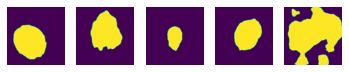

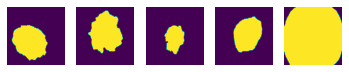

In [17]:
model.eval()
predictions = []
image_mask = []
plots = 5
images, masks = test_dataset[0], test_dataset[1]
for i, (img, mask) in enumerate(zip(images, masks)):
    if i == plots:
        break
    img = img.to(device).unsqueeze(0)
    predictions.append((model(img).detach().cpu()[0] > 0.5).float())
    image_mask.append(mask)
plotn(plots, (predictions, image_mask), only_mask=True)


---

**免责声明**：  
本文档使用AI翻译服务[Co-op Translator](https://github.com/Azure/co-op-translator)进行翻译。尽管我们努力确保准确性，但请注意，自动翻译可能包含错误或不准确之处。应以原始语言的文档作为权威来源。对于关键信息，建议使用专业人工翻译。对于因使用本翻译而引起的任何误解或误读，我们概不负责。
